# Tarea 5 IA Generacion de imagenes con autoencoder
### Javier Alonso Rojas Rojas, Brandon Emmanuel Sanchez Araya, Julio Josue Varela Venegas

In [1]:
import os
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
import lightning as L
import hydra

# Modelo clasico AutoEncoder

In [2]:
import torch.nn as nn

class ClassicAE(nn.Module):
    def __init__(self, latent_dim=128, **kwargs):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # (B, 32, 64, 64)
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # (B, 64, 32, 32)
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # (B, 128, 16, 16)
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),# (B, 256, 8, 8)
            nn.ReLU(),
        )
        self.flatten = nn.Flatten()  # output = 256*8*8 = 16384
        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)


        self.fc_decode = nn.Linear(latent_dim, 256 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 16x16
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 32x32
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 64x64
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # 128x128
            nn.Sigmoid()  # imágen RGB normalizada 0–1
        )

    def forward(self, x):
        # Encode
        z = self.encoder(x)
        z = self.flatten(z)
        z = self.fc_mu(z)

        # Decode
        out = self.fc_decode(z)
        out = out.view(-1, 256, 8, 8)
        out = self.decoder(out)

        return out, z

# Modelo de Unet AutoEncoder

In [3]:
import torch
import torch.nn as nn

class UNetAE(nn.Module):
    def __init__(self, latent_dim=128, **kwargs):
        super().__init__()
        
        # ============================================
        # ENCODER con capas individuales para skip connections
        # ============================================
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # (B, 32, 64, 64)
            nn.ReLU()
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # (B, 64, 32, 32)
            nn.ReLU()
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # (B, 128, 16, 16)
            nn.ReLU()
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),# (B, 256, 8, 8)
            nn.ReLU()
        )
        
        # ============================================
        # BOTTLENECK (Latent Space)
        # ============================================
        self.flatten = nn.Flatten()  # 256*8*8 = 16384
        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 256 * 8 * 8)
        
        # ============================================
        # DECODER con skip connections
        # ============================================
        # Nota: Los canales de entrada se duplican por las skip connections
        
        self.dec1 = nn.Sequential(
            # 256 (from bottleneck) + 256 (skip from enc4) = 512 input channels
            nn.ConvTranspose2d(256 + 256, 128, kernel_size=4, stride=2, padding=1), # 16x16
            nn.ReLU()
        )
        self.dec2 = nn.Sequential(
            # 128 (from dec1) + 128 (skip from enc3) = 256 input channels
            nn.ConvTranspose2d(128 + 128, 64, kernel_size=4, stride=2, padding=1),  # 32x32
            nn.ReLU()
        )
        self.dec3 = nn.Sequential(
            # 64 (from dec2) + 64 (skip from enc2) = 128 input channels
            nn.ConvTranspose2d(64 + 64, 32, kernel_size=4, stride=2, padding=1),   # 64x64
            nn.ReLU()
        )
        self.dec4 = nn.Sequential(
            # 32 (from dec3) + 32 (skip from enc1) = 64 input channels
            nn.ConvTranspose2d(32 + 32, 3, kernel_size=4, stride=2, padding=1),    # 128x128
            nn.Sigmoid()  # imagen RGB normalizada 0-1
        )
    
    def forward(self, x):
        # ============================================
        # ENCODER - Guardar skip connections
        # ============================================
        skip1 = self.enc1(x)       # (B, 32, 64, 64)
        skip2 = self.enc2(skip1)   # (B, 64, 32, 32)
        skip3 = self.enc3(skip2)   # (B, 128, 16, 16)
        skip4 = self.enc4(skip3)   # (B, 256, 8, 8)
        
        # ============================================
        # BOTTLENECK
        # ============================================
        z = self.flatten(skip4)
        z = self.fc_mu(z)
        
        # ============================================
        # DECODER - Usar skip connections
        # ============================================
        out = self.fc_decode(z)
        out = out.view(-1, 256, 8, 8)
        
        # Concatenar skip connection 4
        out = torch.cat([out, skip4], dim=1)  # (B, 512, 8, 8)
        out = self.dec1(out)                   # (B, 128, 16, 16)
        
        # Concatenar skip connection 3
        out = torch.cat([out, skip3], dim=1)  # (B, 256, 16, 16)
        out = self.dec2(out)                   # (B, 64, 32, 32)
        
        # Concatenar skip connection 2
        out = torch.cat([out, skip2], dim=1)  # (B, 128, 32, 32)
        out = self.dec3(out)                   # (B, 32, 64, 64)
        
        # Concatenar skip connection 1
        out = torch.cat([out, skip1], dim=1)  # (B, 64, 64, 64)
        out = self.dec4(out)                   # (B, 3, 128, 128)
        
        return out, z

# Instanciador de Modulo de Pytorch Lightining

In [4]:
import wandb
import matplotlib.pyplot as plt

class LitAutoencoder(L.LightningModule):
    def __init__(self, cfg):
        super().__init__()
        self.model = hydra.utils.instantiate(cfg.model)
        self.loss_fn = hydra.utils.instantiate(cfg.loss)
        self.lr = cfg.trainer.learning_rate

        # para guardar batch de validación
        self.last_val_batch = None

    def training_step(self, batch, _):
        x, _ = batch
        x_rec, z = self.model(x)
        loss = self.loss_fn(x_rec, x)
        self.log("train_loss", loss, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, _ = batch
        x_rec, z = self.model(x)
        loss = self.loss_fn(x_rec, x)

        # guardamos el primer batch para loggear imágenes
        if batch_idx == 0:
            self.last_val_batch = (x.detach(), x_rec.detach())

        self.log("val_loss", loss, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        if self.last_val_batch is None:
            return

        x, x_rec = self.last_val_batch

        # ----------- mostrar en notebook -----------
        if self.current_epoch % 5 == 0:
            fig, axes = plt.subplots(2, 8, figsize=(12, 4))
            for i in range(8):
                axes[0, i].imshow(x[i].permute(1,2,0).cpu())
                axes[0, i].axis("off")
                axes[1, i].imshow(x_rec[i].permute(1,2,0).cpu())
                axes[1, i].axis("off")
            plt.suptitle(f"Reconstructions - Epoch {self.current_epoch}")
            plt.show()
        # ---------------------------------------------------

        # Mandamos a WandB como antes
        imgs = []
        for i in range(min(8, x.size(0))):
            imgs.append(wandb.Image(x[i].cpu(), caption=f"orig_{i}"))
            imgs.append(wandb.Image(x_rec[i].cpu(), caption=f"rec_{i}"))

        self.logger.experiment.log({
            "val/reconstructions": imgs,
            "epoch": self.current_epoch
        })

    def test_step(self, batch, batch_idx):
        x, paths = batch
        x_rec, z = self.model(x)
        loss = self.loss_fn(x_rec, x)

        # log primer batch de test
        if batch_idx == 0:
            imgs = []
            for i in range(min(8, x.size(0))):
                cap = "DEFECT" if "good" not in paths[i] else "GOOD"
                imgs.append(wandb.Image(x[i].cpu(), caption=f"{cap}_orig"))
                imgs.append(wandb.Image(x_rec[i].cpu(), caption=f"{cap}_rec"))

            self.logger.experiment.log({
                "test/reconstructions": imgs,
                "epoch": self.current_epoch
            })

        self.log("test_loss", loss)
        return {"loss": loss, "paths": paths}

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened b

# Manejo del Dataset

### Creacion del validation set, con 20% del training set

In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split

root = "data"
clases = ["cable", "capsule", "screw", "transistor"]

for clase in clases:
    train_good = os.path.join(root, clase, "train", "good")
    val_good = os.path.join(root, clase, "val", "good")
    os.makedirs(val_good, exist_ok=True)

    images = [img for img in os.listdir(train_good) 
              if img.lower().endswith(("png","jpg","jpeg","bmp"))]

    train_imgs, val_imgs = train_test_split(images, test_size=0.20, random_state=42)

    for img in val_imgs:
        src = os.path.join(train_good, img)
        dst = os.path.join(val_good, img)
        shutil.move(src, dst)

    print(f"{clase}: {len(train_imgs)} train, {len(val_imgs)} val")


cable: 36 train, 9 val
capsule: 35 train, 9 val
screw: 52 train, 14 val
transistor: 34 train, 9 val


### Clase auxiliar para cargar folders de imagenes

In [6]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import os

class ImageFolderCustom(Dataset):
    def __init__(self, file_paths, transform=None):
        self.files = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, path


## DataModule de Pytorch Lightning

In [7]:
import os
from torch.utils.data import DataLoader
from torchvision import transforms
import lightning as L

class MVTecMultiClassDataModule(L.LightningDataModule):
    def __init__(self, root="data", batch_size=32, num_workers=4, img_size=128):
        super().__init__()
        self.root = root
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.img_size = img_size

        # Transformación básica (puedes agregar normalización si querés)
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

        # Clases del dataset
        self.classes = ["cable", "capsule", "screw", "transistor"]

    def setup(self, stage=None):
        train_files = []
        val_files = []
        test_files = []

        for clase in self.classes:
            base = f"{self.root}/{clase}"

            # -------------------------------
            # TRAIN (solo good)
            # -------------------------------
            train_dir = f"{base}/train/good"
            if os.path.exists(train_dir):
                train_files.extend([
                    os.path.join(train_dir, f)
                    for f in os.listdir(train_dir)
                    if f.lower().endswith((".png",".jpg",".jpeg",".bmp"))
                ])

            # -------------------------------
            # VAL (solo good)
            # -------------------------------
            val_dir = f"{base}/val/good"
            if os.path.exists(val_dir):
                val_files.extend([
                    os.path.join(val_dir, f)
                    for f in os.listdir(val_dir)
                    if f.lower().endswith((".png",".jpg",".jpeg",".bmp"))
                ])

            # -------------------------------
            # TEST (good + defectos)
            # -------------------------------
            test_root = f"{base}/test"
            if os.path.exists(test_root):
                for subfolder in os.listdir(test_root):
                    subpath = os.path.join(test_root, subfolder)

                    # solo carpetas
                    if not os.path.isdir(subpath):
                        continue

                    # good y defectos
                    test_files.extend([
                        os.path.join(subpath, f)
                        for f in os.listdir(subpath)
                        if f.lower().endswith((".png",".jpg",".jpeg",".bmp"))
                    ])

        # Crear datasets
        self.train_ds = ImageFolderCustom(train_files, transform=self.transform)
        self.val_ds   = ImageFolderCustom(val_files, transform=self.transform)
        self.test_ds  = ImageFolderCustom(test_files, transform=self.transform)

        print(f"[INFO] Train: {len(self.train_ds)} imgs, Val: {len(self.val_ds)} imgs, Test: {len(self.test_ds)} imgs")

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers
        )


# Confirmacion configuración de Hydra

In [11]:
from hydra import initialize_config_dir, compose
from pathlib import Path
import hydra

# Inicializar Hydra
config_dir = Path("conf").absolute()
print(f"Usando directorio de configuración: {config_dir}")

with initialize_config_dir(config_dir=str(config_dir), version_base=None):
    # Cambiar entre experimentos:
    # - classic_l1, classic_l2, classic_ssim, classic_ssim_l1
    # - unet_l1, unet_l2, unet_ssim, unet_ssim_l1
    
    cfg = compose(config_name="config")
    
    print(f"Experimento: {cfg.experiment_name}")
    print(f"Modelo: {cfg.model.name}")
    print(f"Arquitectura: {cfg.model.architecture}")
    print(f"Loss: {cfg.loss._target_}")
    print(f"Latent dim: {cfg.model.latent_dim}")
    print(f"Learning rate: {cfg.trainer.learning_rate}")
    print(f"Max epochs: {cfg.trainer.max_epochs}")
    print(f"Dataset clase: {cfg.dataset}")
    
    # Crear el modelo Lightning
    lit_model = LitAutoencoder(cfg)
    print(f"\nModelo creado: {lit_model.model.__class__.__name__}")

Usando directorio de configuración: /home/javialroro/TEC/2025 II/IA/AutoencoderImageGen/conf
Experimento: classic_ae_l2
Modelo: classic_autoencoder
Arquitectura: classic
Loss: torch.nn.MSELoss
Latent dim: 128
Learning rate: 0.001
Max epochs: 50
Dataset clase: {'_target_': '__main__.MVTecMultiClassDataModule', 'root': 'data', 'batch_size': 32, 'img_size': 128, 'num_workers': 4}

Modelo creado: ClassicAE


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce R

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type      | Params | Mode 
----------------------------------------------
0 | model   | ClassicAE | 5.6 M  | train
1 | loss_fn | MSELoss   | 0      | train
----------------------------------------------
5.6 M     Trainable params
0         Non-trainable params
5.6 M     Total params
22.363    Total estimated model params size (MB)
23        Modules in train mode
0         Modules in eval mode


[INFO] Train: 157 imgs, Val: 819 imgs, Test: 542 imgs
Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  2.51it/s]

/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 32. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


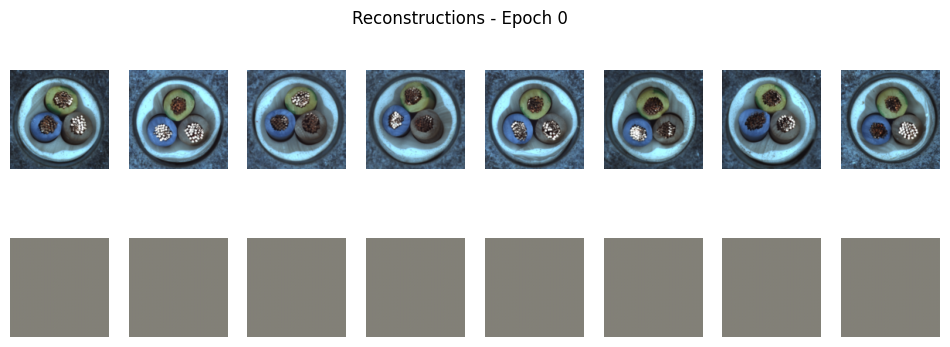

/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (5) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 5/5 [00:02<00:00,  2.22it/s, v_num=nlk6, train_loss=0.0768]

/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 19. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


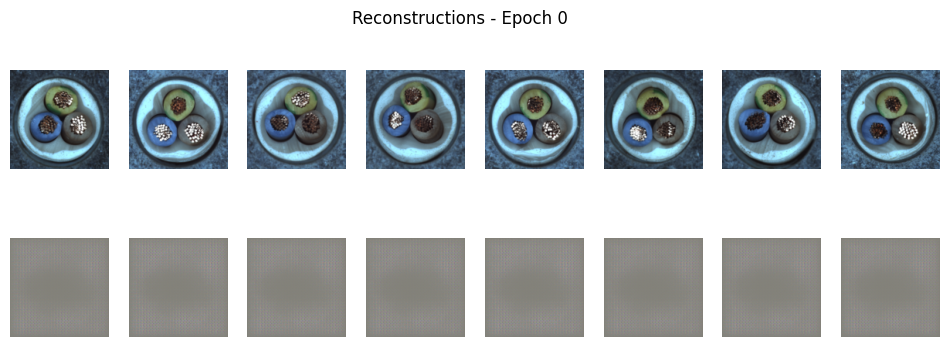

Epoch 5: 100%|██████████| 5/5 [00:02<00:00,  2.33it/s, v_num=nlk6, train_loss=0.0414, val_loss=0.0388]

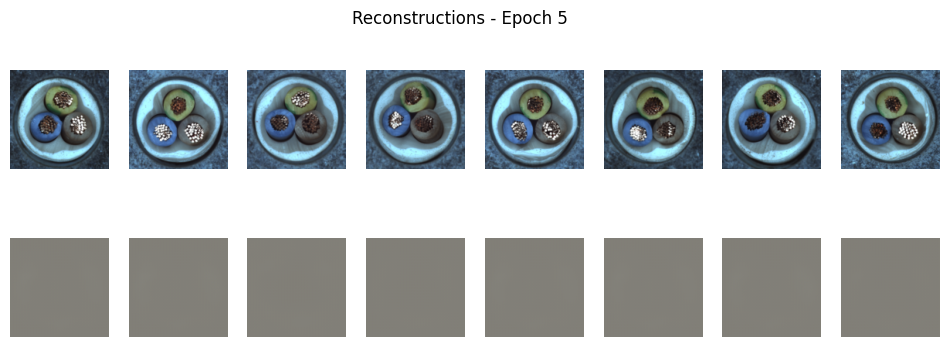

Epoch 10: 100%|██████████| 5/5 [00:02<00:00,  2.08it/s, v_num=nlk6, train_loss=0.0134, val_loss=0.0187]

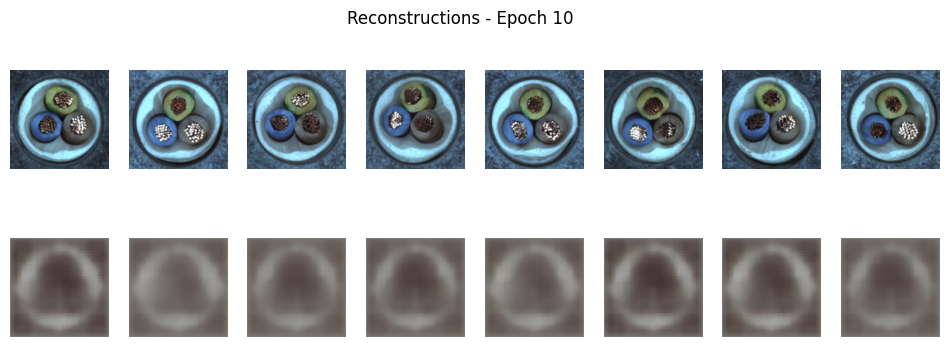

Epoch 15: 100%|██████████| 5/5 [00:02<00:00,  2.02it/s, v_num=nlk6, train_loss=0.00879, val_loss=0.0112]

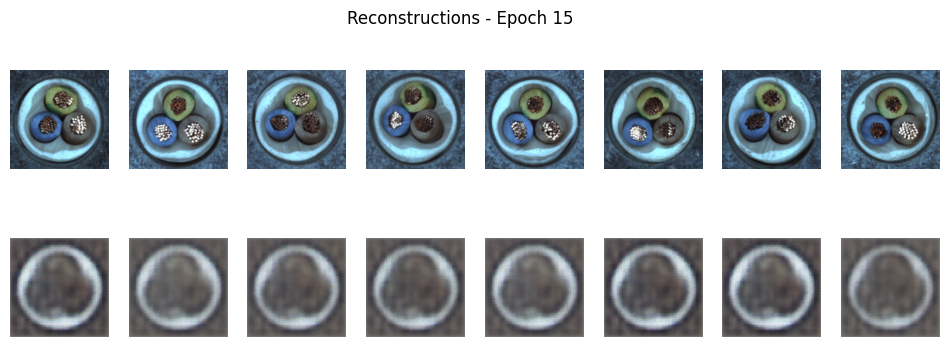

Epoch 20: 100%|██████████| 5/5 [00:02<00:00,  2.02it/s, v_num=nlk6, train_loss=0.00855, val_loss=0.011]  

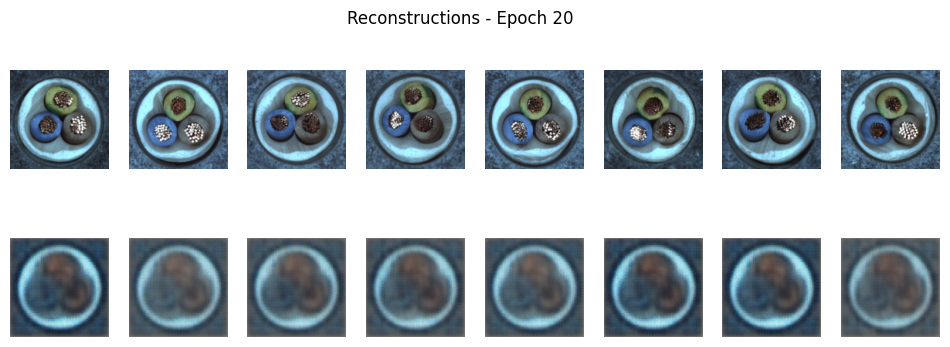

Epoch 25: 100%|██████████| 5/5 [00:02<00:00,  2.18it/s, v_num=nlk6, train_loss=0.00552, val_loss=0.00721]

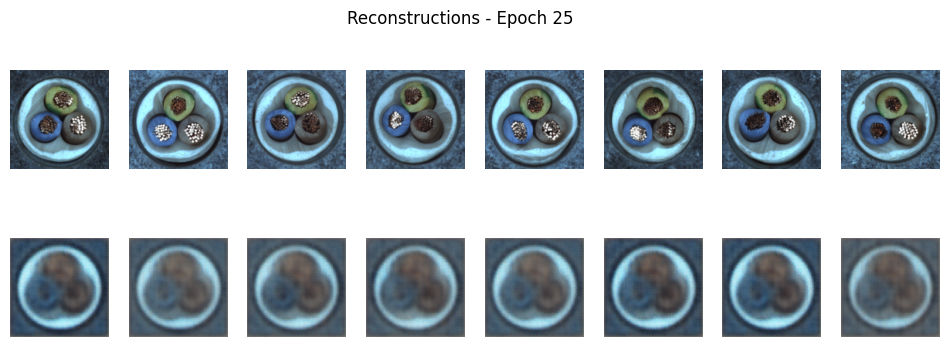

Epoch 30: 100%|██████████| 5/5 [00:03<00:00,  1.61it/s, v_num=nlk6, train_loss=0.00579, val_loss=0.00646]

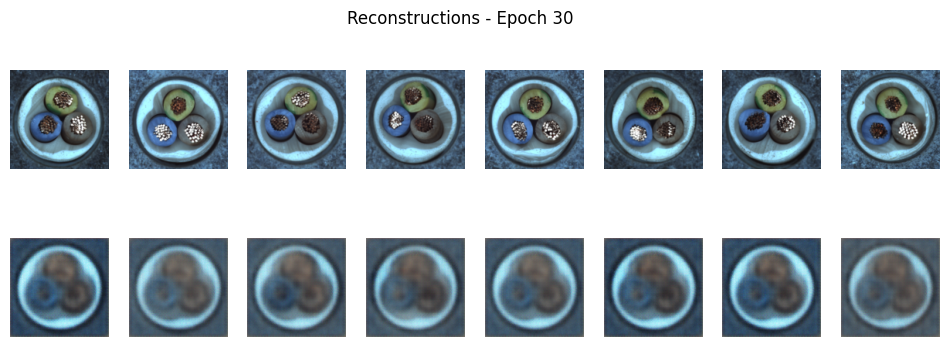

Epoch 35: 100%|██████████| 5/5 [00:02<00:00,  2.09it/s, v_num=nlk6, train_loss=0.00516, val_loss=0.00604]

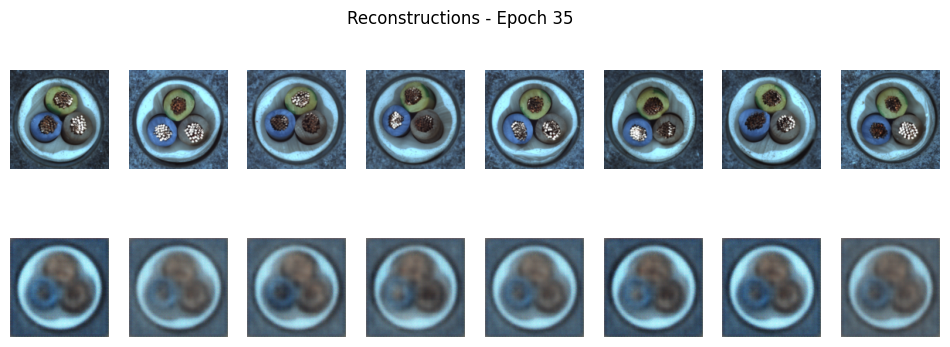

Epoch 40: 100%|██████████| 5/5 [00:02<00:00,  1.76it/s, v_num=nlk6, train_loss=0.00404, val_loss=0.00582]

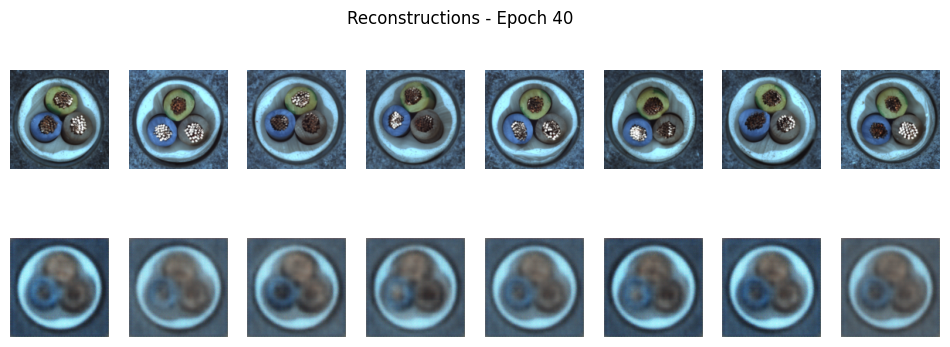

Epoch 45: 100%|██████████| 5/5 [00:02<00:00,  1.85it/s, v_num=nlk6, train_loss=0.00505, val_loss=0.00549]

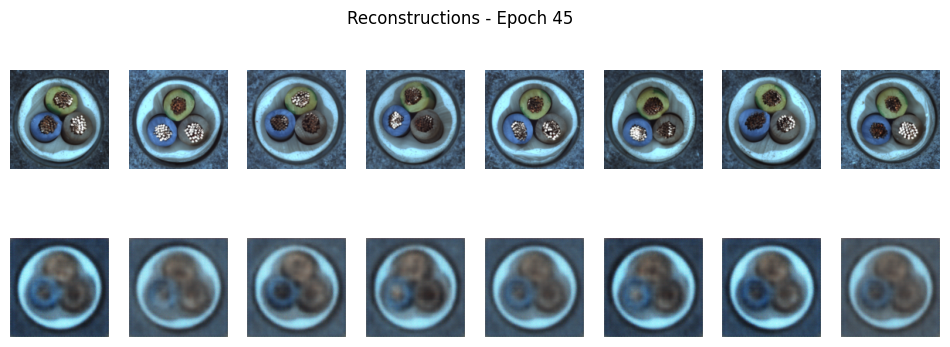

Epoch 49: 100%|██████████| 5/5 [00:12<00:00,  0.39it/s, v_num=nlk6, train_loss=0.004, val_loss=0.00514]  

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 5/5 [00:12<00:00,  0.39it/s, v_num=nlk6, train_loss=0.004, val_loss=0.00514]


In [13]:
dm = hydra.utils.instantiate(cfg.dataset)
model = LitAutoencoder(cfg)

from lightning.pytorch.loggers import WandbLogger

wandb_logger = WandbLogger(
    project="tarea5-autoencoder",
    name=f"{cfg.model.name}_{cfg.loss._target_}_{cfg.dataset}",
    log_model=False  # puedes poner True si quieres guardar pesos en WandB
)

trainer = L.Trainer(
    max_epochs=cfg.trainer.max_epochs,
    logger=wandb_logger
)

trainer.fit(model, dm)
